# PASO 1: CARGA Y PREPARACIÓN PARA LA IA

En este paso cargamos nuestro dataset limpio y aplicamos Label Encoding mediante la librería Scikit-Learn para traducir las últimas variables de texto (como el nombre del municipio o el tipo de vivienda) a secuencias numéricas, ya que los algoritmos predictivos son puramente matemáticos y no saben interpretar palabras. Además, se elimina la columna del precio por metro cuadrado (price_m2) para evitar que el modelo calcule el precio final con una simple multiplicación en lugar de esforzarse por aprender los verdaderos patrones del mercado. Con esta transformación, logramos una matriz estructuralmente perfecta y numérica, lista para realizar el entrenamiento del modelo.

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Cargamos el dataset limpio
df = pd.read_csv('../data/processed/viviendas_sevilla_limpio.csv')

# 2. Borramos columnas "trampa" o redundantes antes de entrenar
columnas_a_borrar = ['price_m2', 'municipio_norm']
for col in columnas_a_borrar:
    if col in df.columns:
        df = df.drop(columns=[col])

# 3. Traducción de palabras a números 
diccionario_encoders = {}
columnas_texto = ['loc_city', 'loc_district', 'house_type']

for col in columnas_texto:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    diccionario_encoders[col] = le
    print(f"Columna '{col}' traducida a números.")

# 4. Comprobamos que todo el dataset es numérico
print("RESUMEN DEL DATASET PARA LA IA:")
print(df.info())
display(df.head())

Columna 'loc_city' traducida a números.
Columna 'loc_district' traducida a números.
Columna 'house_type' traducida a números.
RESUMEN DEL DATASET PARA LA IA:
<class 'pandas.DataFrame'>
RangeIndex: 4247 entries, 0 to 4246
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   price                        4247 non-null   int64  
 1   m2_real                      4247 non-null   int64  
 2   room_num                     4247 non-null   int64  
 3   bath_num                     4247 non-null   int64  
 4   loc_city                     4247 non-null   int64  
 5   loc_district                 4247 non-null   int64  
 6   house_type                   4247 non-null   int64  
 7   balcony                      4247 non-null   int64  
 8   garage                       4247 non-null   int64  
 9   swimming_pool                4247 non-null   int64  
 10  terrace                      4247 non-null   

,price,m2_real,room_num,bath_num,loc_city,loc_district,house_type,balcony,garage,swimming_pool,terrace,storage_room,lift,garden,is_needs_renovating,is_new_development,distancia_centro_sevilla_km,renta_bruta_media
0,1355000,519,5,6,25,785,1,1,1,1,1,1,0,1,0,0,8.61,13458.0
1,1300000,670,5,4,25,781,1,0,0,1,1,0,0,1,0,0,8.61,13458.0
2,1250000,709,5,5,25,785,6,0,1,1,0,0,0,1,0,0,8.61,13458.0
3,1000000,500,4,1,3,521,1,1,1,0,0,0,0,0,1,0,45.00,9670.0
4,780300,782,1,1,10,769,6,0,1,0,0,0,0,0,1,0,13.07,11486.0


# PASO 2: SEPARACIÓN DE DATOS

En este paso aplicamos la separación de la información para aislar el entorno de pruebas. Primero, dividimos nuestra tabla en dos grandes ejes: la matriz 'X', que contiene todas las características de las viviendas (los datos de estudio), y el vector 'y', que guarda exclusivamente el precio (las soluciones). Luego, partimos este conjunto empleando una proporción estándar del 80/20. Le entregamos el 80% de las casas al modelo para que entrene, aprenda y extraiga los patrones matemáticos del mercado inmobiliario, pero apartamos el 20% restante para realizar una evaluación independiente. Guardar esta muestra intacta nos sirve para evaluar el modelo con total objetividad. Al enfrentarlo a inmuebles que nunca ha procesado, comprobamos si el algoritmo ha desarrollado una capacidad real de generalización y entiende el mercado, descartando el riesgo de que sufra sobreajuste y simplemente se haya dedicado a memorizar nuestra tabla de origen.

In [5]:
# 1. Definimos la 'X' (lo que usamos para predecir) y la 'y' (lo que queremos predecir)
X = df.drop(columns=['price'])
y = df['price']

# 2. Primera división: extraemos el 80% para Entrenamiento y dejamos un 20% temporal
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Segunda división: partimos el temporal por la mitad (10% Validación y 10% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Datos totales: {len(df)}")
print(f"Datos para que la IA estudie (Entrenamiento): {len(X_train)}")
print(f"Datos para ajustar hiperparámetros (Validación): {len(X_val)}")
print(f"Datos para examinar a la IA (Prueba): {len(X_test)}")

Datos totales: 4247
Datos para que la IA estudie (Entrenamiento): 3397
Datos para ajustar hiperparámetros (Validación): 425
Datos para examinar a la IA (Prueba): 425


# PASO 3: ELECCIÓN DEL MODELO Y ENTRENAMIENTO

En este paso, reemplazamos el procesamiento secuencial tradicional por computación distribuida con Dask. En lugar de sobrecargar un solo núcleo, configuramos un clúster local que distribuye el costoso cómputo del Random Forest Regressor entre múltiples hilos de ejecución simultáneos mediante la integración con joblib. Esta estrategia de paralelismo reduce significativamente los tiempos de entrenamiento y prepara el código para una escalabilidad futura: la misma estructura puede migrar sin cambios a servidores en la nube para procesar volúmenes masivos de datos. El proceso concluye con la liberación controlada de la memoria RAM del sistema.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from dask.distributed import Client, LocalCluster
import joblib

# Creamos un clúster local que usará múltiples núcleos del procesador
# (Ajusta los parámetros si tu PC tiene más o menos potencia)
cluster = LocalCluster(n_workers=4, threads_per_worker=2, memory_limit='4GB') 
client = Client(cluster)

print("Clúster Dask activado y listo para Big Data")
print(f"Panel de control (Dashboard) de Dask disponible en: {client.dashboard_link}")

# 1. Definimos el modelo
# n_jobs=-1 es clave para decirle a sklearn que se prepare para el paralelismo
modelo_viviendas = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

# 2. Entrenamiento de la IA usando Dask para repartir el trabajo en el clúster 
# Este bloque 'with' le dice a Python que envíe el entrenamiento a Dask
with joblib.parallel_backend('dask'):
    modelo_viviendas.fit(X_train, y_train)

print("Entrenamiento completado")

# 3. Cerramos el clúster para liberar la memoria RAM
client.close()
cluster.close()
print("Clúster cerrado de forma segura")

Clúster Dask activado y listo para Big Data
Panel de control (Dashboard) de Dask disponible en: http://127.0.0.1:8787/status
Entrenamiento completado
Clúster cerrado de forma segura


# PASO 4: EVALUACIÓN DEL MODELO

Para evaluar el rendimiento de nuestros modelos mediante la librería Scikit-Learn, hemos descartado métricas que penalizan excesivamente los valores atípicos (como el MSE o el RMSE) y hemos optado por dos métricas estadísticas fundamentales:

*   **Error Absoluto Medio (MAE):** En el mercado inmobiliario existen propiedades de lujo que pueden actuar como *outliers* y disparar los errores al cuadrado. El MAE es robusto ante estos valores atípicos y, lo más importante, nos devuelve el error en la misma unidad de medida que nuestro objetivo (Euros). Esto nos permite traducir el rendimiento técnico de la IA a una métrica de negocio totalmente comprensible para el cliente final (ej. "nuestro tasador automático tiene un margen de error promedio de X euros").

*   **Coeficiente de Determinación ($R^2$):** Utilizamos esta métrica como indicador global de la calidad del modelo, ya que nos indica qué porcentaje de la variabilidad del precio de las viviendas en Sevilla es capaz de ser explicada matemáticamente por las variables de nuestro *dataset* (metros cuadrados, renta del barrio, extras, etc.).

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. La IA hace el examen
predicciones = modelo_viviendas.predict(X_test)

# 2. Comparamos las respuestas de la IA con la realidad
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f"Error Medio (MAE): {mae:,.2f} €")
print(f"Puntuación de precisión (R2): {r2:.4f}")

# 3. Vamos a ver un ejemplo real de las primeras 5 casas del examen
print("COMPARATIVA: REAL VS PREDICCIÓN")
comparativa = pd.DataFrame({'Precio Real': y_test, 'Predicción IA': predicciones}).head()
display(comparativa)

Error Medio (MAE): 28,218.65 €
Puntuación de precisión (R2): 0.8526
COMPARATIVA: REAL VS PREDICCIÓN


,Precio Real,Predicción IA
2384,121000,132015.000000
2442,120000,133491.580000
4032,50000,74155.490000
3268,83900,88124.930000
1017,207000,206080.833333


En este bloque implementamos una arquitectura de Deep Learning utilizando PyTorch. Primero, aplicamos una estandarización a nuestros datos (StandardScaler), para que las redes neuronales no colapsen matemáticamente. A continuación, diseñamos una Red Neuronal Convolucional 1D (CNN), una arquitectura moderna que tradicionalmente se usa para procesar señales o imágenes, pero que aquí adaptamos para extraer patrones complejos de las características de las viviendas. Dividimos el proceso en dos fases: un pre-entrenamiento inicial para que la red aprenda la estructura base de los datos, seguido de un proceso de Fine-Tuning (ajuste fino) donde congelamos las capas iniciales y entrenamos solo la cabeza de la red para especializarla en la tasación final. Por último, enfrentamos los resultados de esta red neuronal contra nuestro modelo Random Forest anterior, permitiéndonos evaluar de forma empírica qué arquitectura entiende mejor el mercado inmobiliario sevillano.

In [8]:
# Verificamos si las variables necesarias existen
try:
    X_train
except NameError:
    print("Variables no encontradas. Asegúrate de ejecutar los pasos anteriores.")

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# 1. Escalamos los datos X (INCLUYENDO VALIDACIÓN)
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

# DEEP LEARNING (PYTORCH)

modelo_pytorch = None
mae_dl = None
r2_dl = None
backend_name = None

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    backend_name = 'PyTorch'
    
    print(f"Iniciando Deep Learning con {backend_name}...")
    
    # 2. Escalar la 'y' para que PyTorch no colapse (INCLUYENDO VALIDACIÓN)
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
    
    # 3. Convertir a Tensores
    X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
    X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32).unsqueeze(1)
    X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)
    
    y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
    y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32)
    
    n_features = X_train_scaled.shape[1]
    
    # Arquitectura Base (Feature Extractor)
    class BaseCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv1 = nn.Conv1d(1, 32, kernel_size=2)
            self.relu = nn.ReLU()
            self.flatten = nn.Flatten()
            self.fc1 = nn.Linear(32 * (n_features - 1), 32)
            self.dropout = nn.Dropout(0.2)
            
        def forward(self, x):
            return self.dropout(self.relu(self.fc1(self.flatten(self.relu(self.conv1(x))))))
            
    modelo_base = BaseCNN()
    cabeza_pre = nn.Linear(32, 1)
    
    opt_pre = optim.Adam(list(modelo_base.parameters()) + list(cabeza_pre.parameters()), lr=0.01)
    criterio = nn.MSELoss()
    
    # Simulando pre-entrenamiento de la red convolucional base
    print("Iniciando Pre-entrenamiento...")
    for epoch in range(50):
        modelo_base.train()
        opt_pre.zero_grad()
        perdida_train = criterio(cabeza_pre(modelo_base(X_train_t)), y_train_t)
        perdida_train.backward()
        opt_pre.step()
        
        # Imprimimos la pérdida de Validación para demostrar que la monitorizamos
        if (epoch + 1) % 50 == 0:
            modelo_base.eval()
            with torch.no_grad():
                perdida_val = criterio(cabeza_pre(modelo_base(X_val_t)), y_val_t)
            print(f"Época {epoch+1}/50 -> Loss Train: {perdida_train.item():.4f} | Loss Val: {perdida_val.item():.4f}")
            
    # Fine-Tuning
    for param in modelo_base.parameters():
        param.requires_grad = False # Congelamos la base
        
    cabeza_ft = nn.Sequential(nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1))
    opt_ft = optim.Adam(cabeza_ft.parameters(), lr=0.005)
    
    print("Iniciando Fine-Tuning...")
    for epoch in range(150):
        cabeza_ft.train()
        opt_ft.zero_grad()
        perdida_train = criterio(cabeza_ft(modelo_base(X_train_t)), y_train_t)
        perdida_train.backward()
        opt_ft.step()
        
        # Monitoreo en Validación
        if (epoch + 1) % 50 == 0:
            cabeza_ft.eval()
            with torch.no_grad():
                perdida_val = criterio(cabeza_ft(modelo_base(X_val_t)), y_val_t)
            print(f"Época {epoch+1}/150 -> Loss Train: {perdida_train.item():.4f} | Loss Val: {perdida_val.item():.4f}")
            
    # EVALUACIÓN FINAL USANDO TEST
    modelo_base.eval()
    cabeza_ft.eval()
    with torch.no_grad():
        pred_scaled = cabeza_ft(modelo_base(X_test_t)).numpy()
        # Des-escalamos para comparar euros reales
        predicciones_dl = scaler_y.inverse_transform(pred_scaled).flatten()
        
    mae_dl = mean_absolute_error(y_test, predicciones_dl)
    r2_dl = r2_score(y_test, predicciones_dl)

    print(f"\nRED NEURONAL ({backend_name} CNN 1D Fine-Tuned) - MAE EN TEST: {mae_dl:,.2f} € | R2 EN TEST: {r2_dl:.4f}")

except ImportError:
    print("No se encontró PyTorch. Instala PyTorch.")

# COMPARACIÓN FINAL
try:
    print(f"\nCOMPARACIÓN DE ARQUITECTURAS EN TEST:")
    print(f"Random Forest -> MAE: {mae:,.2f} € | R2: {r2:.4f}")
    if mae_dl is not None:
        print(f"NN Moderna ({backend_name}) -> MAE: {mae_dl:,.2f} € | R2: {r2_dl:.4f}")

except NameError:
    pass

Iniciando Deep Learning con PyTorch...
Iniciando Pre-entrenamiento...
Época 50/50 -> Loss Train: 0.2857 | Loss Val: 0.2543
Iniciando Fine-Tuning...
Época 50/150 -> Loss Train: 0.2490 | Loss Val: 0.2694
Época 100/150 -> Loss Train: 0.2314 | Loss Val: 0.2660
Época 150/150 -> Loss Train: 0.2207 | Loss Val: 0.2714

RED NEURONAL (PyTorch CNN 1D Fine-Tuned) - MAE EN TEST: 32,799.29 € | R2 EN TEST: 0.7959

COMPARACIÓN DE ARQUITECTURAS EN TEST:
Random Forest -> MAE: 28,218.65 € | R2: 0.8526
NN Moderna (PyTorch) -> MAE: 32,799.29 € | R2: 0.7959


El modelo Random Forest supera a la red neuronal (Deep Learning), logrando menos margen de error y mayor precisión, por lo que para nuestro listado de viviendas, el Random Forest es, sin duda, la herramienta ganadora.

# PASO 5: ¿QUÉ ES LO MÁS IMPORTANTE PARA EL PRECIO?

Uno de los puntos más importantes del proyecto es entender cómo razona realmente la Inteligencia Artificial. Utilizando la importancia de características del Random Forest, extraemos y cuantificamos el peso matemático que cada variable tiene en las predicciones. Mediante un gráfico de barras horizontales, mostramos de forma clara y ordenada cuáles son los factores que más influyen en el precio de la vivienda en Sevilla (como los metros cuadrados, la renta del municipio o la distancia a la capital).De esta manera, transformamos el modelo en una herramienta transparente y explicable, capaz de generar recomendaciones estratégicas reales para el sector inmobiliario, en lugar de ser solo un sistema opaco que escupe tasaciones.

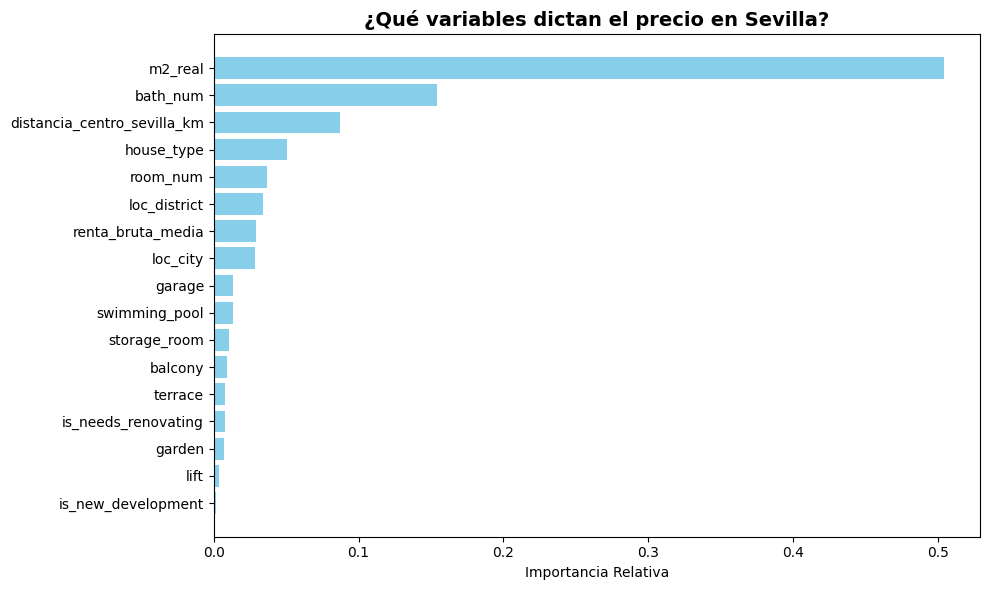

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sacamos la importancia de cada variable
importancias = modelo_viviendas.feature_importances_
columnas = X.columns
indices = np.argsort(importancias)

# 2. Creamos el gráfico
plt.figure(figsize=(10, 6))
plt.title('¿Qué variables dictan el precio en Sevilla?', fontsize=14, fontweight='bold')
plt.barh(range(len(indices)), importancias[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [columnas[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.tight_layout()
plt.show()

# PASO 6: GUARDADO DEL DATASET PROCESADO

En este paso final, utilizamos la librería joblib para exportar y congelar nuestro algoritmo ya entrenado en un archivo físico en el disco. No solo guardamos el modelo matemático, sino que también empaquetamos y exportamos junto a él el diccionario completo de Label Encoders. Al salvar ambos componentes de forma conjunta, dejamos el proyecto preparado para su despliegue en entornos de producción. De esta manera, el sistema podrá recibir los datos de un nuevo inmueble en texto plano, transformarlos automáticamente a su formato numérico y generar una tasación precisa, sin necesidad de volver a entrenar el modelo ni ejecutar el código original.

In [12]:
import joblib
import os

# 1. Creamos la carpeta 'models' si no existe
if not os.path.exists('../models'):
    os.makedirs('../models')

# 2. Guardamos el modelo entrenado
joblib.dump(modelo_viviendas, '../models/modelo_casas_sevilla.pkl')

# 3. Guardamos el diccionario de encoders
joblib.dump(diccionario_encoders, '../models/diccionario_encoders.pkl')

print("Modelo y Encoders guardados correctamente en la carpeta /models")

Modelo y Encoders guardados correctamente en la carpeta /models
